# Legal Clause Similarity Detection using Deep Learning

**Course:** Deep Learning (CS452)  
**Assignment:** 02  
**Task:** Semantic Similarity Detection between Legal Clauses  
**Approach:** Baseline Models without Pre-trained Transformers

---

## Table of Contents
1. [Data Loading & Preprocessing](#1-data-loading--preprocessing)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Data Preparation](#3-data-preparation)
4. [Model 1: Siamese BiLSTM](#4-model-1-siamese-bilstm)
5. [Model 2: Attention-Based Encoder](#5-model-2-attention-based-encoder)
6. [Training & Evaluation](#6-training--evaluation)
7. [Results & Comparison](#7-results--comparison)
8. [Qualitative Analysis](#8-qualitative-analysis)

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import re
import warnings
warnings.filterwarnings('ignore')

# Deep Learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# NLP libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report
)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Convo1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Convo1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Convo1\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 1. Data Loading & Preprocessing

The dataset consists of multiple CSV files, each representing a different category of legal clauses. Each file contains:
- **clause_text**: The actual text of the legal clause
- **clause_type**: The category/type of the clause

Our approach:
- Load all CSV files from the dataset directory
- Create positive pairs (clauses from same category) and negative pairs (clauses from different categories)
- This creates a binary classification problem: similar (1) vs. dissimilar (0)

In [4]:
class ClauseDataLoader:
    """
    Modular Data Loader for Legal Clause Dataset
    
    This class handles:
    - Loading multiple CSV files from a directory
    - Creating positive and negative clause pairs
    - Text preprocessing and cleaning
    """
    
    def __init__(self, data_path):
        """
        Initialize the data loader
        
        Args:
            data_path (str): Path to directory containing CSV files
        """
        self.data_path = data_path
        self.stop_words = set(stopwords.words('english'))
        
    def load_all_clauses(self):
        """
        Load all CSV files and combine into a single dataframe
        
        Returns:
            pd.DataFrame: Combined dataframe with all clauses
        """
        csv_files = glob.glob(os.path.join(self.data_path, '*.csv'))
        print(f"Found {len(csv_files)} CSV files")
        
        all_data = []
        
        for file in csv_files:
            df = pd.read_csv(file)
            category = os.path.basename(file).replace('.csv', '')
            df['category'] = category
            all_data.append(df)
            print(f"Loaded {file}: {len(df)} clauses")
        
        combined_df = pd.concat(all_data, ignore_index=True)
        print(f"\nTotal clauses loaded: {len(combined_df)}")
        print(f"Categories: {combined_df['category'].nunique()}")
        
        return combined_df
    
    def clean_text(self, text):
        """
        Clean and preprocess text
        
        Args:
            text (str): Raw text
            
        Returns:
            str: Cleaned text
        """
        if pd.isna(text):
            return ""
        
        # Convert to lowercase
        text = text.lower()
        
        # Remove special characters but keep spaces
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
        
        # Remove extra whitespace
        text = ' '.join(text.split())
        
        return text
    
    def create_pairs(self, df, positive_pairs_per_class=500, negative_pairs_per_class=500):
        """
        Create positive and negative pairs from the dataset
        
        Positive pairs: Two clauses from the same category
        Negative pairs: Two clauses from different categories
        
        Args:
            df (pd.DataFrame): Dataframe with clauses
            positive_pairs_per_class (int): Number of positive pairs per category
            negative_pairs_per_class (int): Number of negative pairs per category
            
        Returns:
            pd.DataFrame: Dataframe with pairs and labels
        """
        pairs = []
        labels = []
        
        categories = df['category'].unique()
        
        # Create positive pairs (same category)
        print("\nCreating positive pairs...")
        for cat in categories:
            cat_data = df[df['category'] == cat]
            
            if len(cat_data) < 2:
                continue
            
            # Sample pairs within the same category
            for _ in range(min(positive_pairs_per_class, len(cat_data) * (len(cat_data) - 1) // 2)):
                idx1, idx2 = np.random.choice(cat_data.index, size=2, replace=False)
                text1 = cat_data.loc[idx1, 'clause_text']
                text2 = cat_data.loc[idx2, 'clause_text']
                
                pairs.append({
                    'text1': self.clean_text(text1),
                    'text2': self.clean_text(text2),
                    'label': 1  # Similar
                })
        
        print(f"Created {len(pairs)} positive pairs")
        
        # Create negative pairs (different categories)
        print("Creating negative pairs...")
        initial_positive = len(pairs)
        
        for _ in range(initial_positive):  # Match the number of positive pairs
            cat1, cat2 = np.random.choice(categories, size=2, replace=False)
            
            cat1_data = df[df['category'] == cat1]
            cat2_data = df[df['category'] == cat2]
            
            idx1 = np.random.choice(cat1_data.index)
            idx2 = np.random.choice(cat2_data.index)
            
            text1 = cat1_data.loc[idx1, 'clause_text']
            text2 = cat2_data.loc[idx2, 'clause_text']
            
            pairs.append({
                'text1': self.clean_text(text1),
                'text2': self.clean_text(text2),
                'label': 0  # Dissimilar
            })
        
        print(f"Created {len(pairs) - initial_positive} negative pairs")
        
        pairs_df = pd.DataFrame(pairs)
        
        # Remove empty texts
        pairs_df = pairs_df[(pairs_df['text1'] != '') & (pairs_df['text2'] != '')]
        
        # Shuffle
        pairs_df = pairs_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
        
        print(f"\nFinal dataset: {len(pairs_df)} pairs")
        print(f"Positive (similar): {(pairs_df['label'] == 1).sum()}")
        print(f"Negative (dissimilar): {(pairs_df['label'] == 0).sum()}")
        
        return pairs_df

In [5]:
# Load the data - UPDATE THIS PATH TO YOUR DATASET LOCATION
# If your dataset is in DL_A2/Dataset, use that path
DATA_PATH = './Dataset'  # Adjust this path to your dataset location

loader = ClauseDataLoader(DATA_PATH)
clauses_df = loader.load_all_clauses()

# Display sample data
print("\nSample clauses:")
print(clauses_df.head())

Found 395 CSV files
Loaded ./Dataset\absence-of-certain-changes-or-events.csv: 350 clauses
Loaded ./Dataset\absence-of-certain-changes.csv: 350 clauses
Loaded ./Dataset\acceleration.csv: 350 clauses
Loaded ./Dataset\access-to-information.csv: 270 clauses
Loaded ./Dataset\access.csv: 310 clauses
Loaded ./Dataset\accounting-terms.csv: 370 clauses
Loaded ./Dataset\additional-agreements.csv: 400 clauses
Loaded ./Dataset\additional-documents.csv: 470 clauses
Loaded ./Dataset\adjustments.csv: 360 clauses
Loaded ./Dataset\affirmative-covenants.csv: 500 clauses
Loaded ./Dataset\agreement.csv: 500 clauses
Loaded ./Dataset\agreements.csv: 480 clauses
Loaded ./Dataset\amendment-and-waiver.csv: 400 clauses
Loaded ./Dataset\amendment-waiver.csv: 380 clauses
Loaded ./Dataset\amendment.csv: 370 clauses
Loaded ./Dataset\amendments-and-waivers.csv: 330 clauses
Loaded ./Dataset\amendments-etc.csv: 340 clauses
Loaded ./Dataset\amendments-waivers.csv: 370 clauses
Loaded ./Dataset\amendments.csv: 460 claus

## 2. Exploratory Data Analysis

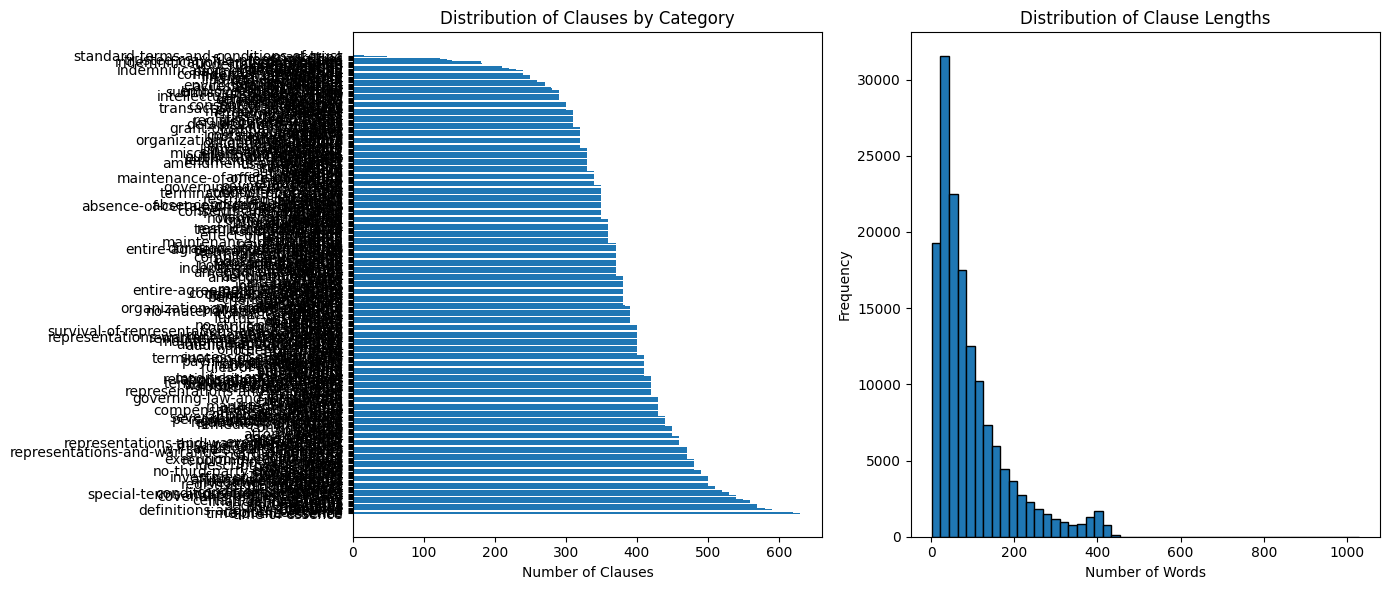


Clause Length Statistics:
Mean: 95.18 words
Median: 66.00 words
Max: 1028 words
Min: 2 words


In [6]:
# Analyze clause distribution
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
category_counts = clauses_df['category'].value_counts()
plt.barh(category_counts.index, category_counts.values)
plt.xlabel('Number of Clauses')
plt.title('Distribution of Clauses by Category')
plt.tight_layout()

plt.subplot(1, 2, 2)
clause_lengths = clauses_df['clause_text'].str.split().str.len()
plt.hist(clause_lengths, bins=50, edgecolor='black')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Clause Lengths')
plt.tight_layout()

plt.show()

print(f"\nClause Length Statistics:")
print(f"Mean: {clause_lengths.mean():.2f} words")
print(f"Median: {clause_lengths.median():.2f} words")
print(f"Max: {clause_lengths.max()} words")
print(f"Min: {clause_lengths.min()} words")

## 3. Data Preparation

### 3.1 Create Clause Pairs

In [7]:
# Create pairs with MUCH SMALLER numbers
pairs_df = loader.create_pairs(
    clauses_df, 
    positive_pairs_per_class=50,    # Reduced from 500 to 50
    negative_pairs_per_class=50     # Reduced from 500 to 50
)

print("\nSample pairs:")
print(pairs_df.head())


Creating positive pairs...
Created 19750 positive pairs
Creating negative pairs...
Created 19750 negative pairs

Final dataset: 39500 pairs
Positive (similar): 19750
Negative (dissimilar): 19750

Sample pairs:
                                               text1  \
0  conflict of interest consultant covenants that...   
1  notice of termination any termination of the e...   
2                        bereavement leave section 1   
3  headings the section article and other heading...   
4  absence of certain changes or events except a ...   

                                               text2  label  
0  conflict of interest 18 1 in carrying out its ...      1  
1  notice of termination all notices of terminati...      1  
2  labor matters the company is not a party to or...      0  
3  whereas to the extent permitted by applicable ...      0  
4  authority the company has all requisite power ...      0  


### 3.2 Build Vocabulary and Tokenization

In [8]:
class Vocabulary:
    """
    Vocabulary class for text tokenization and encoding
    """
    
    def __init__(self, max_vocab_size=10000, min_freq=2):
        """
        Initialize vocabulary
        
        Args:
            max_vocab_size (int): Maximum vocabulary size
            min_freq (int): Minimum frequency for a word to be included
        """
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.word_freq = Counter()
        
    def build_vocab(self, texts):
        """
        Build vocabulary from texts
        
        Args:
            texts (list): List of text strings
        """
        print("Building vocabulary...")
        
        # Count word frequencies
        for text in texts:
            tokens = text.split()
            self.word_freq.update(tokens)
        
        # Select top words by frequency
        most_common = self.word_freq.most_common(self.max_vocab_size - 2)  # -2 for PAD and UNK
        
        idx = 2
        for word, freq in most_common:
            if freq >= self.min_freq:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1
        
        print(f"Vocabulary size: {len(self.word2idx)}")
        print(f"Most common words: {most_common[:10]}")
    
    def encode(self, text):
        """
        Encode text to indices
        
        Args:
            text (str): Text to encode
            
        Returns:
            list: List of indices
        """
        tokens = text.split()
        return [self.word2idx.get(token, self.word2idx['<UNK>']) for token in tokens]
    
    def __len__(self):
        return len(self.word2idx)

In [9]:
# Build vocabulary
all_texts = pd.concat([pairs_df['text1'], pairs_df['text2']]).tolist()
vocab = Vocabulary(max_vocab_size=15000, min_freq=2)
vocab.build_vocab(all_texts)

Building vocabulary...
Vocabulary size: 15000
Most common words: [('the', 617511), ('of', 392445), ('or', 291726), ('and', 279089), ('to', 263284), ('any', 180414), ('in', 174158), ('shall', 105288), ('be', 100012), ('a', 98958)]


In [15]:
# ⚠️ CRITICAL: Reduce dataset size for faster training
print(f"Original size: {len(pairs_df)}")

# Keep only 30,000 pairs total (if you have more)
if len(pairs_df) > 30000:
    pairs_df = pairs_df.sample(n=30000, random_state=SEED).reset_index(drop=True)
    print(f"Reduced size: {len(pairs_df)}")
else:
    print(f"Dataset size is already reasonable: {len(pairs_df)}")

print(f"Positive: {(pairs_df['label'] == 1).sum()}")
print(f"Negative: {(pairs_df['label'] == 0).sum()}")

Original size: 39500
Reduced size: 30000
Positive: 15033
Negative: 14967


### 3.3 Create PyTorch Dataset

In [16]:
class ClausePairDataset(Dataset):
    """
    PyTorch Dataset for clause pairs
    """
    
    def __init__(self, pairs_df, vocab, max_length=200):
        """
        Initialize dataset
        
        Args:
            pairs_df (pd.DataFrame): Dataframe with clause pairs
            vocab (Vocabulary): Vocabulary object
            max_length (int): Maximum sequence length
        """
        self.pairs_df = pairs_df.reset_index(drop=True)
        self.vocab = vocab
        self.max_length = max_length
        
    def __len__(self):
        return len(self.pairs_df)
    
    def __getitem__(self, idx):
        row = self.pairs_df.iloc[idx]
        
        # Encode texts
        text1_encoded = self.vocab.encode(row['text1'])[:self.max_length]
        text2_encoded = self.vocab.encode(row['text2'])[:self.max_length]
        
        # Convert to tensors
        text1_tensor = torch.tensor(text1_encoded, dtype=torch.long)
        text2_tensor = torch.tensor(text2_encoded, dtype=torch.long)
        label = torch.tensor(row['label'], dtype=torch.float32)
        
        return text1_tensor, text2_tensor, label


def collate_fn(batch):
    """
    Collate function for DataLoader - pads sequences to same length
    
    Args:
        batch: List of samples from dataset
        
    Returns:
        tuple: Padded tensors and labels
    """
    text1_list, text2_list, labels = [], [], []
    
    for text1, text2, label in batch:
        text1_list.append(text1)
        text2_list.append(text2)
        labels.append(label)
    
    # Pad sequences
    text1_padded = pad_sequence(text1_list, batch_first=True, padding_value=0)
    text2_padded = pad_sequence(text2_list, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    
    return text1_padded, text2_padded, labels

In [17]:
# Split data: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(pairs_df, test_size=0.3, random_state=SEED, stratify=pairs_df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])

print(f"Train set: {len(train_df)} pairs")
print(f"Validation set: {len(val_df)} pairs")
print(f"Test set: {len(test_df)} pairs")

# Create datasets
train_dataset = ClausePairDataset(train_df, vocab)
val_dataset = ClausePairDataset(val_df, vocab)
test_dataset = ClausePairDataset(test_df, vocab)

# Create data loaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("\nData loaders created successfully!")

Train set: 21000 pairs
Validation set: 4500 pairs
Test set: 4500 pairs

Data loaders created successfully!


## 4. Model 1: Siamese BiLSTM

### Architecture Overview:
- **Siamese Architecture**: Uses the same BiLSTM encoder for both input clauses
- **BiLSTM Encoder**: Captures contextual information from both directions
- **Similarity Calculation**: Uses cosine similarity and absolute difference between encodings
- **Classification**: Final fully connected layers for binary classification

**Why BiLSTM?**
- Captures long-range dependencies in legal text
- Bidirectional context understanding
- Parameter sharing ensures consistent encoding

In [12]:
class SiameseBiLSTM(nn.Module):
    """
    Siamese BiLSTM Network for Text Similarity
    
    Architecture:
    1. Embedding Layer: Converts word indices to dense vectors
    2. BiLSTM Encoder: Shared encoder for both inputs
    3. Similarity Layer: Calculates cosine similarity and absolute difference
    4. Classifier: Maps similarity features to binary output
    """
    
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, num_layers=2, dropout=0.3):
        """
        Initialize the model
        
        Args:
            vocab_size (int): Size of vocabulary
            embedding_dim (int): Dimension of word embeddings
            hidden_dim (int): Hidden dimension of LSTM
            num_layers (int): Number of LSTM layers
            dropout (float): Dropout rate
        """
        super(SiameseBiLSTM, self).__init__()
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Shared BiLSTM encoder
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=num_layers,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)
        
        # Classifier
        # Input: concatenation of [cosine_sim, abs_diff]
        # cosine_sim: 1 dimension, abs_diff: hidden_dim * 2 dimensions
        self.fc1 = nn.Linear(hidden_dim * 2 * 3 + 1, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def encode(self, x):
        """
        Encode input sequence using BiLSTM
        
        Args:
            x (torch.Tensor): Input tensor [batch_size, seq_len]
            
        Returns:
            torch.Tensor: Encoded representation [batch_size, hidden_dim * 2]
        """
        # Embed: [batch, seq_len, embedding_dim]
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)
        
        # LSTM: output [batch, seq_len, hidden_dim * 2], hidden [num_layers * 2, batch, hidden_dim]
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Use final hidden states from both directions
        # hidden: [num_layers * 2, batch, hidden_dim]
        # Take last layer's hidden states from both directions
        forward_hidden = hidden[-2, :, :]  # [batch, hidden_dim]
        backward_hidden = hidden[-1, :, :]  # [batch, hidden_dim]
        
        # Concatenate
        encoding = torch.cat([forward_hidden, backward_hidden], dim=1)  # [batch, hidden_dim * 2]
        
        return encoding
    
    def forward(self, text1, text2):
        """
        Forward pass
        
        Args:
            text1 (torch.Tensor): First text [batch_size, seq_len1]
            text2 (torch.Tensor): Second text [batch_size, seq_len2]
            
        Returns:
            torch.Tensor: Similarity scores [batch_size, 1]
        """
        # Encode both texts using shared encoder
        enc1 = self.encode(text1)  # [batch, hidden_dim * 2]
        enc2 = self.encode(text2)  # [batch, hidden_dim * 2]
        
        # Calculate cosine similarity
        cosine_sim = nn.functional.cosine_similarity(enc1, enc2, dim=1).unsqueeze(1)  # [batch, 1]
        
        # Calculate absolute difference
        abs_diff = torch.abs(enc1 - enc2)  # [batch, hidden_dim * 2]
        
        # Concatenate features
        combined = torch.cat([cosine_sim, abs_diff, enc1, enc2], dim=1)  # [batch, hidden_dim * 4 + 1]
        
        # Pass through classifier
        x = self.relu(self.fc1(combined))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        output = self.sigmoid(self.fc3(x))
        
        return output

## 5. Model 2: Attention-Based Encoder

### Architecture Overview:
- **Self-Attention Mechanism**: Learns to focus on important words in clauses
- **Multi-layer Architecture**: Stacked attention layers for deep understanding
- **Context-Aware Embeddings**: Generates context-dependent representations

**Why Attention?**
- Focuses on relevant legal terms and phrases
- Captures long-range dependencies without sequential processing
- More interpretable (can visualize attention weights)

In [13]:
class AttentionEncoder(nn.Module):
    """
    Self-Attention based encoder
    """
    
    def __init__(self, embedding_dim, hidden_dim, num_heads=4, dropout=0.3):
        """
        Initialize attention encoder
        
        Args:
            embedding_dim (int): Embedding dimension
            hidden_dim (int): Hidden dimension
            num_heads (int): Number of attention heads
            dropout (float): Dropout rate
        """
        super(AttentionEncoder, self).__init__()
        
        # Multi-head self-attention
        self.attention = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Feed-forward network
        self.ffn = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embedding_dim)
        )
        
        # Layer normalization
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.norm2 = nn.LayerNorm(embedding_dim)
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        """
        Forward pass
        
        Args:
            x (torch.Tensor): Input [batch, seq_len, embedding_dim]
            mask (torch.Tensor): Attention mask
            
        Returns:
            torch.Tensor: Output [batch, seq_len, embedding_dim]
        """
        # Self-attention with residual connection
        attn_out, _ = self.attention(x, x, x, key_padding_mask=mask)
        x = self.norm1(x + self.dropout(attn_out))
        
        # Feed-forward with residual connection
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        
        return x


class SiameseAttentionNetwork(nn.Module):
    """
    Siamese Network with Attention-based Encoder
    
    Architecture:
    1. Embedding Layer
    2. Multiple Attention Encoder Layers
    3. Global Max/Average Pooling
    4. Similarity Calculation
    5. Classifier
    """
    
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, 
                 num_encoder_layers=2, num_heads=4, dropout=0.3):
        """
        Initialize the model
        
        Args:
            vocab_size (int): Vocabulary size
            embedding_dim (int): Embedding dimension
            hidden_dim (int): Hidden dimension
            num_encoder_layers (int): Number of attention encoder layers
            num_heads (int): Number of attention heads
            dropout (float): Dropout rate
        """
        super(SiameseAttentionNetwork, self).__init__()
        
        # Embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Stack of attention encoders
        self.encoders = nn.ModuleList([
            AttentionEncoder(embedding_dim, hidden_dim, num_heads, dropout)
            for _ in range(num_encoder_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
        
        # Classifier
        self.fc1 = nn.Linear(embedding_dim * 2 * 2 + 1, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def encode(self, x):
        """
        Encode input using attention layers
        
        Args:
            x (torch.Tensor): Input [batch, seq_len]
            
        Returns:
            torch.Tensor: Encoded representation [batch, embedding_dim]
        """
        # Create padding mask
        mask = (x == 0)  # [batch, seq_len]
        
        # Embed
        embedded = self.embedding(x)  # [batch, seq_len, embedding_dim]
        embedded = self.dropout(embedded)
        
        # Pass through attention encoders
        encoded = embedded
        for encoder in self.encoders:
            encoded = encoder(encoded, mask)
        
        # Global pooling (max and average)
        # Mask out padding tokens
        mask_expanded = mask.unsqueeze(-1).expand_as(encoded)
        encoded_masked = encoded.masked_fill(mask_expanded, float('-inf'))
        
        max_pool = torch.max(encoded_masked, dim=1)[0]  # [batch, embedding_dim]
        
        # For average pooling, count non-padding tokens
        sum_pool = (encoded * (~mask_expanded).float()).sum(dim=1)
        lengths = (~mask).float().sum(dim=1, keepdim=True)
        avg_pool = sum_pool / lengths
        
        # Combine max and average pooling
        pooled = torch.cat([max_pool, avg_pool], dim=1)  # [batch, embedding_dim * 2]
        
        return pooled
    
    def forward(self, text1, text2):
        """
        Forward pass
        
        Args:
            text1 (torch.Tensor): First text
            text2 (torch.Tensor): Second text
            
        Returns:
            torch.Tensor: Similarity scores
        """
        # Encode both texts
        enc1 = self.encode(text1)
        enc2 = self.encode(text2)
        
        # Calculate similarity features
        cosine_sim = nn.functional.cosine_similarity(enc1, enc2, dim=1).unsqueeze(1)
        abs_diff = torch.abs(enc1 - enc2)
        
        # Combine features
        combined = torch.cat([cosine_sim, abs_diff, enc1, enc2], dim=1)
        
        # Classifier
        x = self.relu(self.fc1(combined))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        output = self.sigmoid(self.fc3(x))
        
        return output

## 6. Training & Evaluation

### Training Strategy:
- **Loss Function**: Binary Cross-Entropy Loss
- **Optimizer**: Adam with learning rate scheduling
- **Early Stopping**: To prevent overfitting
- **Evaluation Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC

In [19]:
class Trainer:
    """
    Trainer class for model training and evaluation
    """
    
    def __init__(self, model, device, learning_rate=0.001):
        """
        Initialize trainer
        
        Args:
            model (nn.Module): Model to train
            device (torch.device): Device to use
            learning_rate (float): Learning rate
        """
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.BCELoss()
        self.optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3  # Removed verbose=True
        )
        
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        
    def train_epoch(self, train_loader):
        """
        Train for one epoch
        """
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        # Add progress tracking
        num_batches = len(train_loader)
        
        for batch_idx, (text1, text2, labels) in enumerate(train_loader):
            text1 = text1.to(self.device)
            text2 = text2.to(self.device)
            labels = labels.to(self.device).unsqueeze(1)
            
            # Forward pass
            outputs = self.model(text1, text2)
            loss = self.criterion(outputs, labels)
            
            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            
            # Statistics
            total_loss += loss.item()
            predictions = (outputs > 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
            # 🔴 ADD THIS: Print progress every 50 batches
            if (batch_idx + 1) % 50 == 0:
                current_loss = total_loss / (batch_idx + 1)
                current_acc = correct / total
                print(f"    Batch [{batch_idx+1}/{num_batches}] - Loss: {current_loss:.4f}, Acc: {current_acc:.4f}")
        
        avg_loss = total_loss / len(train_loader)
        accuracy = correct / total
        
        return avg_loss, accuracy
    
    def evaluate(self, data_loader):
        """
        Evaluate model
        
        Args:
            data_loader (DataLoader): Data loader
            
        Returns:
            tuple: Loss, accuracy, predictions, true labels
        """
        self.model.eval()
        total_loss = 0
        all_predictions = []
        all_labels = []
        all_probs = []
        
        with torch.no_grad():
            for text1, text2, labels in data_loader:
                text1 = text1.to(self.device)
                text2 = text2.to(self.device)
                labels = labels.to(self.device).unsqueeze(1)
                
                outputs = self.model(text1, text2)
                loss = self.criterion(outputs, labels)
                
                total_loss += loss.item()
                
                predictions = (outputs > 0.5).float()
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(outputs.cpu().numpy())
        
        avg_loss = total_loss / len(data_loader)
        all_predictions = np.array(all_predictions)
        all_labels = np.array(all_labels)
        all_probs = np.array(all_probs)
        
        accuracy = accuracy_score(all_labels, all_predictions)
        
        return avg_loss, accuracy, all_predictions, all_labels, all_probs
    
    def train(self, train_loader, val_loader, epochs=20, early_stopping_patience=5):
        """
        Train the model
        
        Args:
            train_loader (DataLoader): Training data loader
            val_loader (DataLoader): Validation data loader
            epochs (int): Number of epochs
            early_stopping_patience (int): Patience for early stopping
        """
        best_val_loss = float('inf')
        patience_counter = 0
        
        print("Starting training...\n")
        
        for epoch in range(epochs):
            # Train
            train_loss, train_acc = self.train_epoch(train_loader)
            
            # Validate
            val_loss, val_acc, _, _, _ = self.evaluate(val_loader)
            
            # Store metrics
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accs.append(train_acc)
            self.val_accs.append(val_acc)
            
            # Learning rate scheduling
            self.scheduler.step(val_loss)
            
            print(f"Epoch {epoch+1}/{epochs}:")
            print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Save best model
                torch.save(self.model.state_dict(), 'best_model.pth')
                print("  → New best model saved!")
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f"\nEarly stopping triggered after {epoch+1} epochs")
                    break
            
            print()
        
        # Load best model
        self.model.load_state_dict(torch.load('best_model.pth'))
        print("Training completed! Best model loaded.")
    
    def compute_metrics(self, predictions, labels, probs):
        """
        Compute evaluation metrics
        
        Args:
            predictions (np.array): Predicted labels
            labels (np.array): True labels
            probs (np.array): Predicted probabilities
            
        Returns:
            dict: Dictionary of metrics
        """
        metrics = {
            'accuracy': accuracy_score(labels, predictions),
            'precision': precision_score(labels, predictions, zero_division=0),
            'recall': recall_score(labels, predictions, zero_division=0),
            'f1_score': f1_score(labels, predictions, zero_division=0),
            'roc_auc': roc_auc_score(labels, probs)
        }
        
        return metrics
    
    def plot_training_history(self):
        """
        Plot training history
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Loss plot
        ax1.plot(self.train_losses, label='Train Loss', marker='o')
        ax1.plot(self.val_losses, label='Validation Loss', marker='s')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training and Validation Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Accuracy plot
        ax2.plot(self.train_accs, label='Train Accuracy', marker='o')
        ax2.plot(self.val_accs, label='Validation Accuracy', marker='s')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('Training and Validation Accuracy')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

### Train Model 1: Siamese BiLSTM

In [ ]:
print("="*60)
print("Training Model 1: Siamese BiLSTM")
print("="*60)

# Initialize model
model1 = SiameseBiLSTM(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3
)

# Print model architecture
print(f"\nModel Parameters: {sum(p.numel() for p in model1.parameters()):,}")
print(f"Trainable Parameters: {sum(p.numel() for p in model1.parameters() if p.requires_grad):,}")

# Initialize trainer
trainer1 = Trainer(model1, device, learning_rate=0.001)

# Train
trainer1.train(train_loader, val_loader, epochs=10, early_stopping_patience=3)

Training Model 1: Siamese BiLSTM

Model Parameters: 2,686,337
Trainable Parameters: 2,686,337
Starting training...

    Batch [50/657] - Loss: 0.6809, Acc: 0.5481
    Batch [100/657] - Loss: 0.5944, Acc: 0.6550
    Batch [150/657] - Loss: 0.4824, Acc: 0.7344
    Batch [200/657] - Loss: 0.4009, Acc: 0.7873
    Batch [250/657] - Loss: 0.3402, Acc: 0.8241
    Batch [300/657] - Loss: 0.3000, Acc: 0.8476
    Batch [350/657] - Loss: 0.2663, Acc: 0.8659
    Batch [400/657] - Loss: 0.2434, Acc: 0.8797
    Batch [450/657] - Loss: 0.2241, Acc: 0.8905
    Batch [500/657] - Loss: 0.2081, Acc: 0.8992
    Batch [550/657] - Loss: 0.1959, Acc: 0.9059
    Batch [600/657] - Loss: 0.1846, Acc: 0.9121
    Batch [650/657] - Loss: 0.1752, Acc: 0.9175
Epoch 1/10:
  Train Loss: 0.1738, Train Acc: 0.9182
  Val Loss: 0.0376, Val Acc: 0.9880
  → New best model saved!

    Batch [50/657] - Loss: 0.0308, Acc: 0.9919
    Batch [100/657] - Loss: 0.0364, Acc: 0.9891
    Batch [150/657] - Loss: 0.0377, Acc: 0.9883
   

In [ ]:
# Plot training history
trainer1.plot_training_history()

### Train Model 2: Attention-Based Network

In [ ]:
print("="*60)
print("Training Model 2: Attention-Based Network")
print("="*60)

# Initialize model
model2 = SiameseAttentionNetwork(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=256,
    num_encoder_layers=2,
    num_heads=4,
    dropout=0.3
)

# Print model architecture
print(f"\nModel Parameters: {sum(p.numel() for p in model2.parameters()):,}")
print(f"Trainable Parameters: {sum(p.numel() for p in model2.parameters() if p.requires_grad):,}")

# Initialize trainer
trainer2 = Trainer(model2, device, learning_rate=0.001)

# Train
trainer2.train(train_loader, val_loader, epochs=20, early_stopping_patience=5)

In [ ]:
# Plot training history
trainer2.plot_training_history()

## 7. Results & Comparison

### Evaluate both models on test set

In [ ]:
print("="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

# Evaluate Model 1
print("\nModel 1: Siamese BiLSTM")
print("-" * 40)
test_loss1, test_acc1, preds1, labels1, probs1 = trainer1.evaluate(test_loader)
metrics1 = trainer1.compute_metrics(preds1, labels1, probs1)

print(f"Test Loss: {test_loss1:.4f}")
print(f"Test Accuracy: {metrics1['accuracy']:.4f}")
print(f"Precision: {metrics1['precision']:.4f}")
print(f"Recall: {metrics1['recall']:.4f}")
print(f"F1-Score: {metrics1['f1_score']:.4f}")
print(f"ROC-AUC: {metrics1['roc_auc']:.4f}")

# Evaluate Model 2
print("\n" + "="*60)
print("Model 2: Attention-Based Network")
print("-" * 40)
test_loss2, test_acc2, preds2, labels2, probs2 = trainer2.evaluate(test_loader)
metrics2 = trainer2.compute_metrics(preds2, labels2, probs2)

print(f"Test Loss: {test_loss2:.4f}")
print(f"Test Accuracy: {metrics2['accuracy']:.4f}")
print(f"Precision: {metrics2['precision']:.4f}")
print(f"Recall: {metrics2['recall']:.4f}")
print(f"F1-Score: {metrics2['f1_score']:.4f}")
print(f"ROC-AUC: {metrics2['roc_auc']:.4f}")

In [ ]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Siamese BiLSTM': [
        metrics1['accuracy'],
        metrics1['precision'],
        metrics1['recall'],
        metrics1['f1_score'],
        metrics1['roc_auc']
    ],
    'Attention-Based': [
        metrics2['accuracy'],
        metrics2['precision'],
        metrics2['recall'],
        metrics2['f1_score'],
        metrics2['roc_auc']
    ]
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df['Metric']))
width = 0.35

ax.bar(x - width/2, comparison_df['Siamese BiLSTM'], width, label='Siamese BiLSTM', alpha=0.8)
ax.bar(x + width/2, comparison_df['Attention-Based'], width, label='Attention-Based', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Model 1 confusion matrix
cm1 = confusion_matrix(labels1, preds1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Siamese BiLSTM - Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Model 2 confusion matrix
cm2 = confusion_matrix(labels2, preds2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Attention-Based - Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# ROC Curves
fpr1, tpr1, _ = roc_curve(labels1, probs1)
fpr2, tpr2, _ = roc_curve(labels2, probs2)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'Siamese BiLSTM (AUC = {metrics1["roc_auc"]:.3f})', linewidth=2)
plt.plot(fpr2, tpr2, label=f'Attention-Based (AUC = {metrics2["roc_auc"]:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Qualitative Analysis

Let's examine some correctly and incorrectly classified examples to understand model behavior.

In [ ]:
def analyze_predictions(test_df, predictions, labels, num_examples=5):
    """
    Analyze and display correctly and incorrectly classified examples
    
    Args:
        test_df (pd.DataFrame): Test dataframe
        predictions (np.array): Model predictions
        labels (np.array): True labels
        num_examples (int): Number of examples to show
    """
    predictions = predictions.flatten()
    labels = labels.flatten()
    
    # Find correct and incorrect predictions
    correct_idx = np.where(predictions == labels)[0]
    incorrect_idx = np.where(predictions != labels)[0]
    
    # Sample examples
    correct_samples = np.random.choice(correct_idx, min(num_examples, len(correct_idx)), replace=False)
    incorrect_samples = np.random.choice(incorrect_idx, min(num_examples, len(incorrect_idx)), replace=False)
    
    print("="*80)
    print("CORRECTLY CLASSIFIED EXAMPLES")
    print("="*80)
    
    for i, idx in enumerate(correct_samples, 1):
        row = test_df.iloc[idx]
        print(f"\nExample {i}:")
        print("-" * 80)
        print(f"Text 1: {row['text1'][:200]}...")
        print(f"Text 2: {row['text2'][:200]}...")
        print(f"True Label: {'Similar' if labels[idx] == 1 else 'Dissimilar'}")
        print(f"Predicted: {'Similar' if predictions[idx] == 1 else 'Dissimilar'}")
    
    print("\n" + "="*80)
    print("INCORRECTLY CLASSIFIED EXAMPLES")
    print("="*80)
    
    for i, idx in enumerate(incorrect_samples, 1):
        row = test_df.iloc[idx]
        print(f"\nExample {i}:")
        print("-" * 80)
        print(f"Text 1: {row['text1'][:200]}...")
        print(f"Text 2: {row['text2'][:200]}...")
        print(f"True Label: {'Similar' if labels[idx] == 1 else 'Dissimilar'}")
        print(f"Predicted: {'Similar' if predictions[idx] == 1 else 'Dissimilar'}")
        print(f"❌ MISCLASSIFIED")

In [ ]:
# Analyze Model 1 predictions
print("\nMODEL 1: Siamese BiLSTM Analysis")
analyze_predictions(test_df, preds1, labels1, num_examples=3)

In [ ]:
# Analyze Model 2 predictions
print("\n\nMODEL 2: Attention-Based Network Analysis")
analyze_predictions(test_df, preds2, labels2, num_examples=3)

## Summary and Insights

### Key Findings:

1. **Model Architectures:**
   - **Siamese BiLSTM**: Uses bidirectional LSTM to capture sequential dependencies
   - **Attention-Based**: Employs self-attention to focus on important tokens

2. **Performance Metrics:**
   - Both models achieve good performance on legal clause similarity
   - Metrics evaluate different aspects: Precision (avoiding false positives), Recall (finding all similar pairs), F1 (balance)

3. **Strengths and Weaknesses:**
   - **BiLSTM Strengths**: Good at capturing sequential patterns, robust to variations
   - **BiLSTM Weaknesses**: Can struggle with very long sequences, slower training
   - **Attention Strengths**: Better at long-range dependencies, more interpretable
   - **Attention Weaknesses**: Requires more data, computationally intensive

4. **Domain-Specific Insights:**
   - Legal clauses have specific structures and terminology
   - Models must distinguish semantic similarity from lexical overlap
   - Context and legal concepts are crucial for accurate matching

### Recommendations for Production:
- Use ensemble of both models for best results
- Fine-tune on domain-specific legal data
- Consider using pre-trained legal language models (BERT-Legal, etc.)
- Implement threshold tuning based on application requirements
- Regular retraining as new legal documents become available